# Premium Prediction for Health insurance

# Step-1 : EDA

In [102]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
# loading dataset
df = pd.read_excel("premium_rest_data.xlsx")
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,Female,Northwest,Unmarried,2,Underweight,No Smoking,Salaried,25L - 40L,27,No Disease,Bronze,7452
32433,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Diabetes & Thyroid,Gold,29496
32434,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,<10L,4,No Disease,Bronze,10957
32435,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076


# EDA + Data Cleaning

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32437 entries, 0 to 32436
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    32437 non-null  int64 
 1   Gender                 32437 non-null  object
 2   Region                 32437 non-null  object
 3   Marital_status         32437 non-null  object
 4   Number Of Dependants   32437 non-null  int64 
 5   BMI_Category           32437 non-null  object
 6   Smoking_Status         32428 non-null  object
 7   Employment_Status      32436 non-null  object
 8   Income_Level           32428 non-null  object
 9   Income_Lakhs           32437 non-null  int64 
 10  Medical History        32437 non-null  object
 11  Insurance_Plan         32437 non-null  object
 12  Annual_Premium_Amount  32437 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


In [105]:
df.Income_Level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L', nan], dtype=object)

In [106]:
df.shape

(32437, 13)

In [107]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [108]:
df.columns = df.columns.str.replace(" " , "_")

In [109]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number_Of_Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical_History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [110]:
df.columns = df.columns.str.lower()

In [111]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

## Handle the Null values

In [112]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [113]:
df.dropna(inplace = True)

In [114]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [115]:
df.shape

(32419, 13)

## Handle duplicate values

In [116]:
df.duplicated().sum()

np.int64(0)

In [117]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,32419.000000,32419.000000,32419.000000,32419.000000
mean,41.958759,2.251242,23.220210,19885.373454
std,13.791997,1.468032,24.457152,7541.154293
min,25.000000,-3.000000,1.000000,3508.000000
25%,32.000000,1.000000,7.000000,13996.000000
50%,41.000000,2.000000,17.000000,19698.000000
75%,51.000000,3.000000,32.000000,25739.500000
max,356.000000,5.000000,930.000000,43471.000000


# Numerical columns : Univariate analysis

In [118]:
## Issue-1 : number_of_dependants cannot be in negative

df[df.number_of_dependants < 0]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
1951,34,Female,Southeast,Married,-1,Underweight,Regular,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Silver,22995
2468,41,Male,Southwest,Married,-1,Obesity,Regular,Salaried,10L - 25L,21,Diabetes,Silver,22766
3823,56,Male,Southwest,Married,-3,Normal,Occasional,Salaried,10L - 25L,16,Thyroid,Bronze,11979
4239,26,Male,Southeast,Married,-1,Obesity,Occasional,Freelancer,25L - 40L,27,No Disease,Silver,18269
5054,25,Male,Northwest,Unmarried,-1,Underweight,No Smoking,Salaried,10L - 25L,13,No Disease,Bronze,7234
5312,37,Male,Northwest,Married,-1,Overweight,Regular,Self-Employed,<10L,8,Diabetes,Bronze,13664
6410,42,Female,Southeast,Unmarried,-3,Overweight,Regular,Self-Employed,<10L,8,Diabetes & Heart disease,Bronze,17779
7684,50,Female,Northwest,Married,-3,Normal,Occasional,Salaried,<10L,4,Diabetes & High blood pressure,Silver,21957
7825,47,Male,Northwest,Unmarried,-3,Overweight,Occasional,Self-Employed,10L - 25L,19,No Disease,Gold,27457
8183,39,Male,Southwest,Unmarried,-1,Overweight,Occasional,Self-Employed,25L - 40L,40,High blood pressure,Silver,18406


In [119]:
df.number_of_dependants.unique()

array([ 0,  2,  3,  4,  1,  5, -1, -3])

In [120]:
df['number_of_dependants'] = df.number_of_dependants.abs()

In [121]:
df.number_of_dependants.unique()

array([0, 2, 3, 4, 1, 5])

In [122]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,32419.000000,32419.000000,32419.000000,32419.000000
mean,41.958759,2.257226,23.220210,19885.373454
std,13.791997,1.458814,24.457152,7541.154293
min,25.000000,0.000000,1.000000,3508.000000
25%,32.000000,1.000000,7.000000,13996.000000
50%,41.000000,2.000000,17.000000,19698.000000
75%,51.000000,3.000000,32.000000,25739.500000
max,356.000000,5.000000,930.000000,43471.000000


## Handle the Outliers

In [123]:
numeric_columns = df.select_dtypes(include = ['int64', 'float64']).columns
numeric_columns                             

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

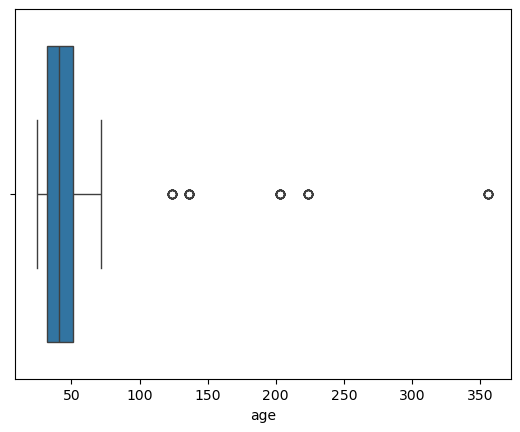

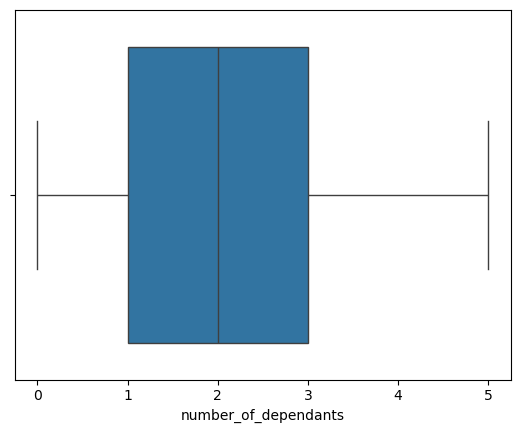

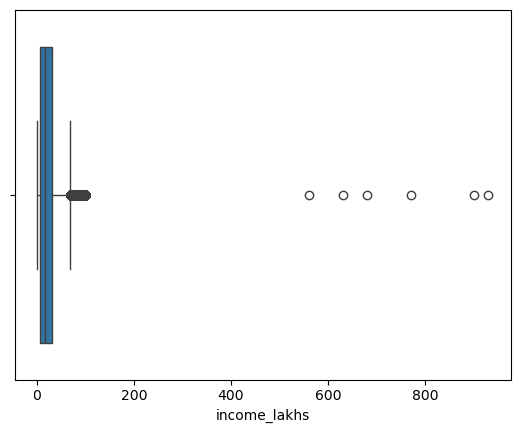

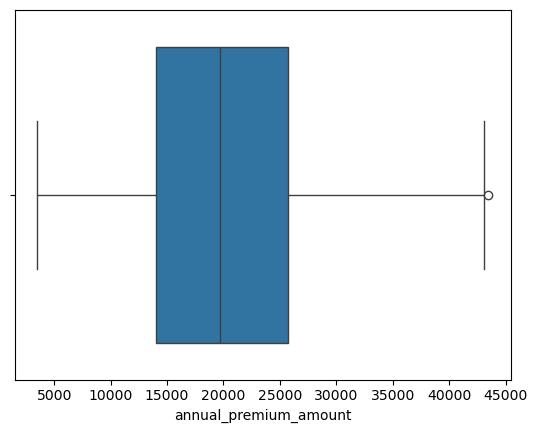

In [124]:
for col in numeric_columns:
    sns.boxplot(x = df[col])
    plt.show()

## Handling the Age Outlier

In [125]:
df[df.age > 100]['age'].count()

np.int64(58)

In [126]:
df[df.age > 100]['age'].unique()

array([224, 124, 136, 203, 356])

In [127]:
median = df.age.median()
median

41.0

In [128]:
df.loc[df.age > 100, 'age'] = median

In [129]:
df[df.age > 100]['age'].count()

np.int64(0)

In [130]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,32419.000000,32419.000000,32419.000000,32419.000000
mean,41.677782,2.257226,23.220210,19885.373454
std,11.651774,1.458814,24.457152,7541.154293
min,25.000000,0.000000,1.000000,3508.000000
25%,32.000000,1.000000,7.000000,13996.000000
50%,41.000000,2.000000,17.000000,19698.000000
75%,51.000000,3.000000,32.000000,25739.500000
max,72.000000,5.000000,930.000000,43471.000000


In [131]:
## Outliers in income_lakhs > 1CR (100)

df[df.income_lakhs > 100]['income_lakhs'].count()

np.int64(6)

In [132]:
# Number of outliers using IQR

Q1, Q3 = df.income_lakhs.quantile([0.25, 0.75])
IQR = Q3 - Q1
LB = Q1 - 1.5 * IQR
UB = Q3 + 1.5 * IQR

LB, UB

(-30.5, 69.5)

In [133]:
df[df.income_lakhs > UB]['income_lakhs'].count()

np.int64(2226)

In [134]:
df = df[df.income_lakhs <= 100]

In [135]:
df.shape

(32413, 13)

In [136]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,32413.000000,32413.000000,32413.000000,32413.000000
mean,41.677074,2.257150,23.086601,19884.070774
std,11.652197,1.458819,22.324760,7540.875715
min,25.000000,0.000000,1.000000,3508.000000
25%,32.000000,1.000000,7.000000,13995.000000
50%,41.000000,2.000000,17.000000,19692.000000
75%,51.000000,3.000000,32.000000,25733.000000
max,72.000000,5.000000,100.000000,43471.000000


# EDA & DC on Caegorical data

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32413 entries, 0 to 32436
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    32413 non-null  int64 
 1   gender                 32413 non-null  object
 2   region                 32413 non-null  object
 3   marital_status         32413 non-null  object
 4   number_of_dependants   32413 non-null  int64 
 5   bmi_category           32413 non-null  object
 6   smoking_status         32413 non-null  object
 7   employment_status      32413 non-null  object
 8   income_level           32413 non-null  object
 9   income_lakhs           32413 non-null  int64 
 10  medical_history        32413 non-null  object
 11  insurance_plan         32413 non-null  object
 12  annual_premium_amount  32413 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 3.5+ MB


In [138]:
categorical_columns = df.select_dtypes(include = ['object']).columns
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [139]:
# checking sub-categories of each column
for col in categorical_columns:
    print(col, " : ", df[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status  :  ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status  :  ['Salaried' 'Self-Employed' 'Freelancer']
income_level  :  ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history  :  ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan  :  ['Bronze' 'Silver' 'Gold']


In [140]:
df['smoking_status'] = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' :  'No Smoking'})

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_20604\2744095914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['smoking_status'] = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' :  'No Smoking'})


In [141]:
df.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [142]:
df.shape

(32413, 13)

# Step-2 : Feature Engineering

In [143]:
# checking sub-categories of each column
for col in categorical_columns:
    print(col, " : ", df[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status  :  ['No Smoking' 'Regular' 'Occasional']
employment_status  :  ['Salaried' 'Self-Employed' 'Freelancer']
income_level  :  ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history  :  ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan  :  ['Bronze' 'Silver' 'Gold']


In [144]:
risk_score = {
    'Diabetes' : 6,
    'Heart disease' : 8,
    'High blood pressure' : 6,
    'Thyroid' : 5,
    'No Disease' : 0
}

In [145]:
df1 = df.copy()

In [146]:
df1[['disease1', 'disease2']] = df1['medical_history'].str.split(" & ", expand = True)

In [147]:
df1.disease1 = df1.disease1.map(risk_score)

In [148]:
df1.disease2 = df1.disease2.map(risk_score)

In [149]:
df1.disease1.isnull().sum()

np.int64(0)

In [150]:
df1.disease2.isnull().sum()

np.int64(28518)

In [151]:
df1.disease2 = df1.disease2.fillna(0)

In [152]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,6,0.0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,6,0.0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,6,0.0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,0.0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,6,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,Female,Northwest,Unmarried,2,Underweight,No Smoking,Salaried,25L - 40L,27,No Disease,Bronze,7452,0,0.0
32433,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Diabetes & Thyroid,Gold,29496,6,5.0
32434,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,<10L,4,No Disease,Bronze,10957,0,0.0
32435,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076,5,0.0


In [153]:
df1['total_risk_score'] = df1['disease1'] + df1['disease2']

In [154]:
df1 = df1.drop(['medical_history', 'disease1', 'disease2'], axis = 1)
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Bronze,9053,6.0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Bronze,16339,6.0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,18164,6.0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,20303,0.0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Bronze,15610,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,Female,Northwest,Unmarried,2,Underweight,No Smoking,Salaried,25L - 40L,27,Bronze,7452,0.0
32433,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Gold,29496,11.0
32434,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,<10L,4,Bronze,10957,0.0
32435,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Gold,27076,5.0


In [155]:
# checking sub-categories of each column
categorical_columns = df1.select_dtypes(include = ['object']).columns
categorical_columns

for col in categorical_columns:
    print(col, " : ", df1[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status  :  ['No Smoking' 'Regular' 'Occasional']
employment_status  :  ['Salaried' 'Self-Employed' 'Freelancer']
income_level  :  ['<10L' '10L - 25L' '> 40L' '25L - 40L']
insurance_plan  :  ['Bronze' 'Silver' 'Gold']


### Apply Ordinal encoding to convert insurance_plan & income_level into neumerical

In [156]:
# use ordinal encoding when Order/Ranking matters

In [157]:
from sklearn.preprocessing import OrdinalEncoder

In [158]:
encoder = OrdinalEncoder(categories = [['Bronze','Silver','Gold']])
df1['insurance_plan'] = encoder.fit_transform(df1[['insurance_plan']])

In [159]:
encoder = OrdinalEncoder(categories = [['<10L','10L - 25L','25L - 40L', '> 40L']])
df1['income_level'] = encoder.fit_transform(df1[['income_level']])

In [160]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,0.0,6,0.0,9053,6.0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,0.0,6,0.0,16339,6.0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,1.0,20,1.0,18164,6.0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,3.0,77,2.0,20303,0.0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,1.0,14,0.0,15610,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,Female,Northwest,Unmarried,2,Underweight,No Smoking,Salaried,2.0,27,0.0,7452,0.0
32433,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,1.0,16,2.0,29496,11.0
32434,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,0.0,4,0.0,10957,0.0
32435,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,3.0,82,2.0,27076,5.0


## Apply Label encoder on region and bmi_category

In [161]:
# Order/Ranking don't matter in Label encoding

In [162]:
from sklearn.preprocessing import LabelEncoder

In [163]:
encoder = LabelEncoder()
for col in ['region', 'bmi_category']:
    df1[col] = encoder.fit_transform(df1[col])

In [164]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,26,Male,1,Unmarried,0,0,No Smoking,Salaried,0.0,6,0.0,9053,6.0
1,29,Female,2,Married,2,1,Regular,Salaried,0.0,6,0.0,16339,6.0
2,49,Female,0,Married,2,0,No Smoking,Self-Employed,1.0,20,1.0,18164,6.0
3,30,Female,2,Married,3,0,No Smoking,Salaried,3.0,77,2.0,20303,0.0
4,56,Male,0,Married,3,1,Occasional,Self-Employed,1.0,14,0.0,15610,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,Female,1,Unmarried,2,3,No Smoking,Salaried,2.0,27,0.0,7452,0.0
32433,40,Female,2,Unmarried,0,2,Regular,Salaried,1.0,16,2.0,29496,11.0
32434,37,Female,1,Unmarried,0,1,No Smoking,Salaried,0.0,4,0.0,10957,0.0
32435,47,Female,2,Married,2,0,No Smoking,Salaried,3.0,82,2.0,27076,5.0


### convert into numeric using one-hot encoding

In [165]:
df.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [166]:
df1 = pd.get_dummies(df1, columns = ['gender', 'marital_status', 'smoking_status', 'employment_status'], drop_first = True, dtype = int)

In [167]:
df1

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,1,0,0,0.0,6,0.0,9053,6.0,1,1,0,0,1,0
1,29,2,2,1,0.0,6,0.0,16339,6.0,0,0,0,1,1,0
2,49,0,2,0,1.0,20,1.0,18164,6.0,0,0,0,0,0,1
3,30,2,3,0,3.0,77,2.0,20303,0.0,0,0,0,0,1,0
4,56,0,3,1,1.0,14,0.0,15610,6.0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,1,2,3,2.0,27,0.0,7452,0.0,0,1,0,0,1,0
32433,40,2,0,2,1.0,16,2.0,29496,11.0,0,1,0,1,1,0
32434,37,1,0,1,0.0,4,0.0,10957,0.0,0,1,0,0,1,0
32435,47,2,2,0,3.0,82,2.0,27076,5.0,0,0,0,0,1,0


## finding correlation 

<Axes: >

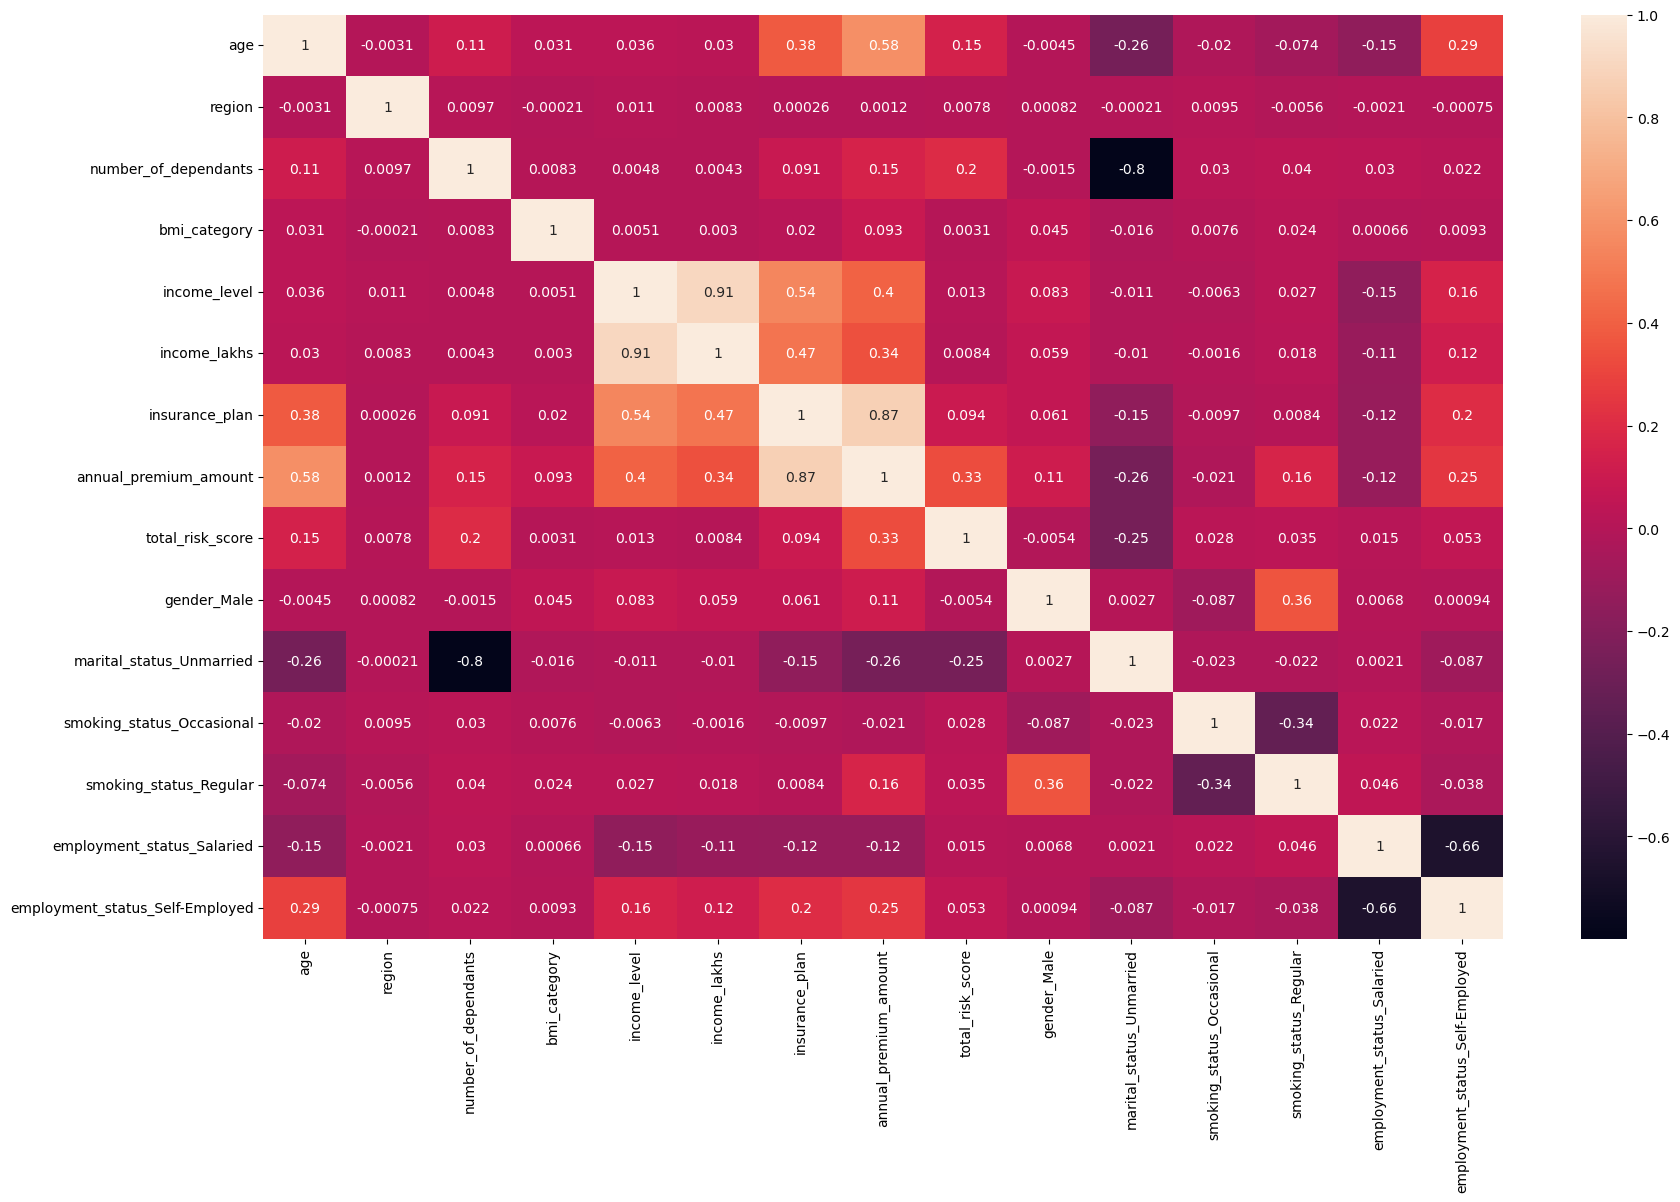

In [168]:
cm = df1.corr()

plt.figure(figsize = (20,12))
sns.heatmap(cm, annot = True)



# income_level = income_lakhs   & number_of_dependents = marital_status_unmarried

In [169]:
# income_level = income_lakhs   & number_of_dependents = marital_status_unmarried

## feature scaling

In [170]:
x = df1.drop(["income_level", "marital_status_Unmarried", "annual_premium_amount"], axis = 1)
y = df1.annual_premium_amount
x.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'insurance_plan', 'total_risk_score', 'gender_Male',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [171]:
from sklearn.model_selection import train_test_split

In [172]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [173]:
from sklearn.preprocessing import MinMaxScaler   # 0 to 1

scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [174]:
x_train_scaled.shape

(25930, 12)

In [175]:
x_test_scaled.shape

(6483, 12)

# Step-3 : Apply ML models

### Linear Regression

In [176]:
from sklearn.linear_model import LinearRegression

linear_obj = LinearRegression()

linear_obj.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [177]:
lr_score = linear_obj.score(x_test_scaled, y_test)
print(lr_score)

0.9120198988164657


### model-2 : XGBoost

In [178]:
from xgboost import XGBRegressor

In [179]:
XGB_obj = XGBRegressor()

In [180]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
                'n_estimators' : [50, 60, 70, 80, 90, 100],
                'max_depth' : [3,4,5,6,7,8,9,10]
}

random_search = RandomizedSearchCV(XGB_obj, param_grid, cv = 5)

In [181]:
random_search.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [3, 4, ...], 'n_estimators': [50, 60, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold t

In [182]:
random_search.best_score_

np.float64(0.9935929536819458)

# CONGRATULATIONS - TARGET-1 ACHIEVED

# TARGET-2

In [183]:
y_pred = random_search.predict(x_test_scaled)
y_pred

array([14906.122, 33773.793, 22584.   , ..., 21346.357, 25457.432,
       17565.703], dtype=float32)

In [184]:
residuals = y_pred - y_test

residuals_pct = (residuals / y_test) * 100
residuals_pct

31096     0.249661
17852     1.037464
4759      0.893495
28897     1.770152
14505   -21.900153
           ...    
3539     -2.547191
10720     0.727119
11828    -2.062959
19093    -1.533876
30165    -1.543057
Name: annual_premium_amount, Length: 6483, dtype: float64

In [185]:
result_df = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_pred,
    'diff' : residuals,
    'diff_pct' : residuals_pct })

result_df 

,Actual,Predicted,diff,diff_pct
31096,14869,14906.122070,37.122070,0.249661
17852,33427,33773.792969,346.792969,1.037464
4759,22384,22584.000000,200.000000,0.893495
28897,21684,22067.839844,383.839844,1.770152
14505,13515,10555.194336,-2959.805664,-21.900153
...,...,...,...,...
3539,10788,10513.208984,-274.791016,-2.547191
10720,24806,24986.369141,180.369141,0.727119
11828,21796,21346.357422,-449.642578,-2.062959
19093,25854,25457.431641,-396.568359,-1.533876


<Axes: xlabel='diff_pct', ylabel='Count'>

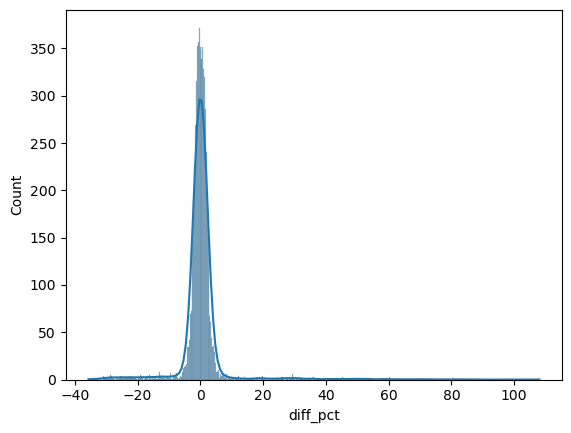

In [186]:
sns.histplot(result_df ['diff_pct'], kde = True)

In [187]:
extreme_result_df = result_df[np.abs(result_df.diff_pct) > 10]
extreme_result_df 

,Actual,Predicted,diff,diff_pct
14505,13515,10555.194336,-2959.805664,-21.900153
10189,8842,6413.386230,-2428.613770,-27.466792
32213,7221,6364.205078,-856.794922,-11.865322
30902,13325,10094.818359,-3230.181641,-24.241513
25397,7598,10390.738281,2792.738281,36.756229
...,...,...,...,...
1339,9890,7448.204590,-2441.795410,-24.689539
24548,4648,7613.876465,2965.876465,63.809735
12935,10984,13854.479492,2870.479492,26.133280
328,7617,10699.719727,3082.719727,40.471573


### Create extreme_result_df with all the features

In [188]:
extreme_error_df = x_test.loc[extreme_result_df.index]
extreme_error_df

error_percentage = (extreme_error_df.shape[0] / x_test.shape[0]) * 100
print(error_percentage)

5.876908838500694


In [189]:
extreme_error_df.age.unique()

array([25, 41])

### Finding the problem at Data level

In [190]:
df1.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'insurance_plan', 'annual_premium_amount',
       'total_risk_score', 'gender_Male', 'marital_status_Unmarried',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [191]:
# We need to find due to which feature "predicted - actual" difference is high

<Axes: xlabel='age', ylabel='Count'>

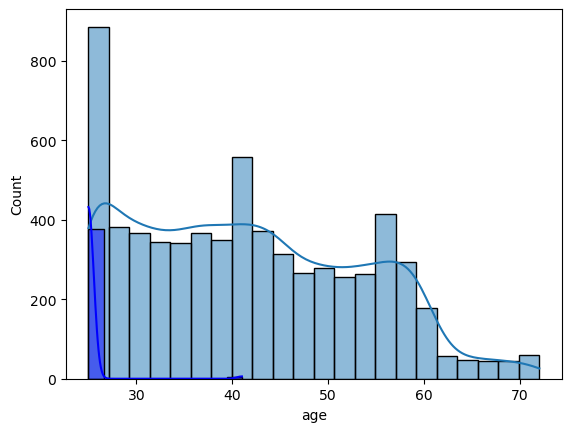

In [192]:
sns.histplot(x_test['age'], kde = True)
sns.histplot(extreme_error_df['age'], color = 'blue', kde = True)

<Axes: xlabel='region', ylabel='Count'>

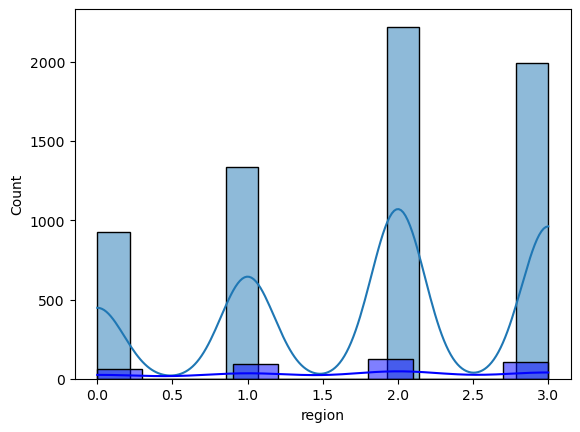

In [193]:
sns.histplot(x_test['region'], kde = True)
sns.histplot(extreme_error_df['region'], color = 'blue', kde = True)

In [194]:
x_test.shape

(6483, 12)

In [195]:
extreme_error_df.shape

(381, 12)

In [196]:
# if the shape of error data and actual data is different for a feature
# that's means problem is occuring due to that particular feature

<Axes: xlabel='number_of_dependants', ylabel='Count'>

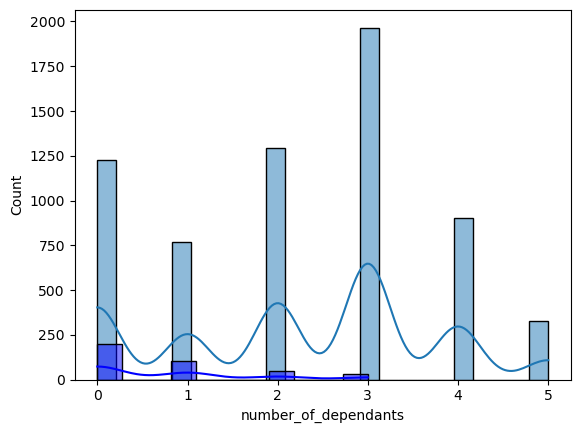

In [197]:
sns.histplot(x_test['number_of_dependants'], kde = True)
sns.histplot(extreme_error_df['number_of_dependants'], color = 'blue', kde = True)

In [198]:
type(x_test)

pandas.core.frame.DataFrame

In [199]:
x_test[x_test.age < 24]

,age,region,number_of_dependants,bmi_category,income_lakhs,insurance_plan,total_risk_score,gender_Male,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed


In [200]:
# People with age less then 24 are unpredicatable

# people whose age < 24, their the "predict - actual' difference is more

# Data Segmentation